# PDAN8411 - Programming for Data Analytics 1
## ICE Task 2 - Linear Regression for Medical Aid Cost Prediction

**Student:** Sifiso Mahlangu

Uses the Medical Insurance dataset (Kaggle, mirichoi0218/insurance) to
explore what drives medical insurance charges, then trains a Linear
Regression model to predict them.


## Task 1: Import required libraries

pandas and numpy for the data, matplotlib and seaborn for the graphs,
scikit-learn for the split, the model and the evaluation metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## Task 2: Load and explore the dataset

1338 records of medical aid clients. Each row is one client:

| Column | What it is |
|---|---|
| age | age of the client |
| sex | male or female |
| bmi | body mass index |
| children | number of dependants |
| smoker | yes or no |
| region | where in the US they live |
| charges | medical insurance cost, this is the target |


In [2]:
df = pd.read_csv("insurance.csv")
print(df.shape)
df.head()


(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [4]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.describe().round(2)


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


**Interpretation:** 1338 records, no missing values anywhere, so the data
does not need cleaning. Four numeric columns (age, bmi, children, charges)
and three text columns (sex, smoker, region), which is why sex, smoker and
region will need converting to numbers before the model can use them.
Charges range from about 1122 to 63770, and the mean (13270) sitting well
above the median (9382) already hints the charges are skewed rather than
evenly spread, which the histogram below confirms.


## Task 3: Exploratory data analysis

Four graphs, each answering a different question: what charges look like on
their own, how the numeric features relate to charges and each other, how
much smoking matters, and whether bmi and smoking interact.


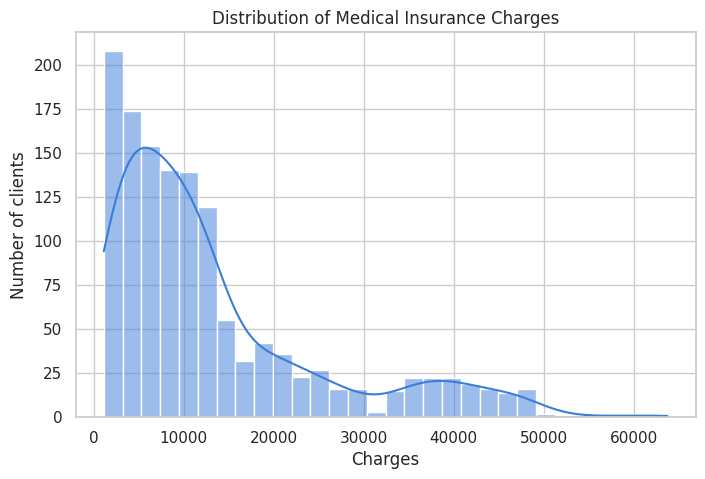

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="charges", bins=30, kde=True, color="#3B7DD8")
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Number of clients")
plt.show()


**Interpretation:** heavily right skewed, most clients are charged under
15000, but a long tail stretches out past 50000. Most people cost relatively
little to insure, and a smaller group costs a lot more.


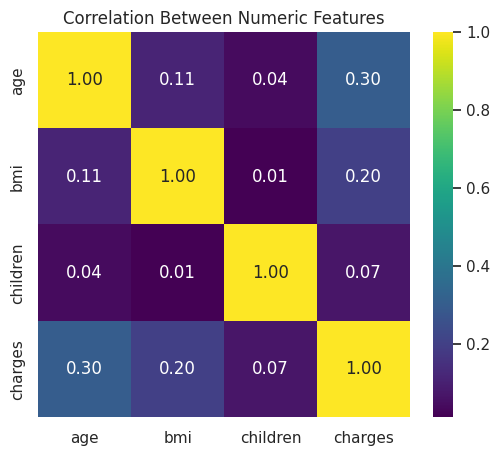

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["age", "bmi", "children", "charges"]].corr(), annot=True,
            cmap="viridis", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()


**Interpretation:** age (0.30) and bmi (0.20) both have a positive but
fairly weak relationship with charges on their own, children barely matters
(0.07). None of these numeric features explain charges by themselves, which
points to smoker status, a category, being the bigger driver.


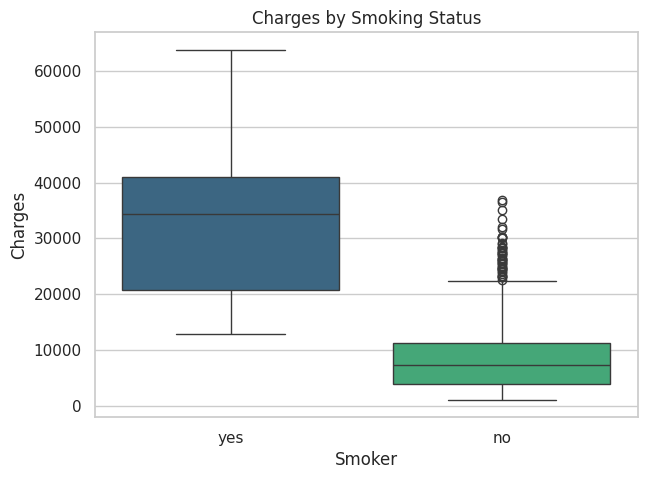

In [8]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker",
            palette="viridis", legend=False)
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()


In [9]:
df.groupby("smoker")["charges"].mean().round(2)


smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64

**Interpretation:** this is the clearest pattern in the whole dataset.
Smokers pay 32050 on average, non-smokers pay 8434, nearly 4 times less.
The two boxes barely overlap. Smoker status looks like the single strongest
predictor of charges, well ahead of age or bmi.


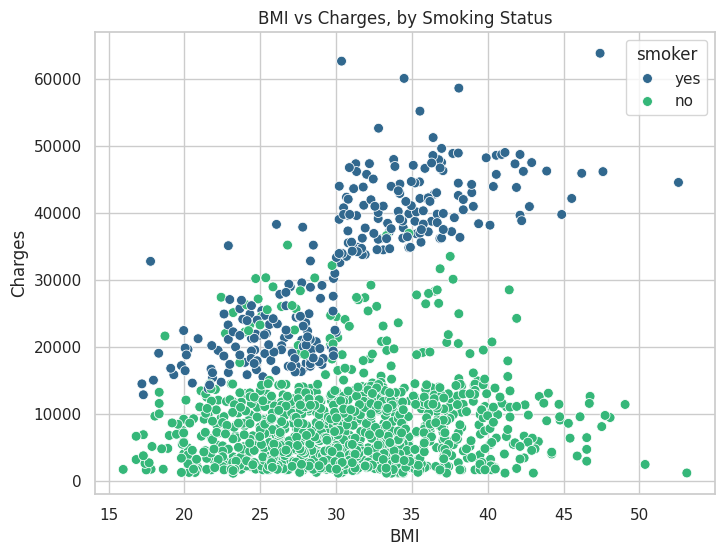

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                 palette="viridis", s=50)
plt.title("BMI vs Charges, by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()


**Interpretation:** bmi on its own barely relates to charges for
non-smokers, that group stays fairly flat and low across the whole bmi
range. For smokers though, charges climb sharply as bmi rises. bmi and
smoking interact, a high bmi is far more expensive for a smoker than for a
non-smoker.


## Task 4: Data preprocessing

Categorical features such as sex, smoker and region must be converted to
numerical values because machine learning algorithms require numeric
inputs. Using one-hot encoding (`pd.get_dummies`) with `drop_first=True` so
each category avoids adding a redundant column.


In [11]:
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)
df_encoded.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


**Interpretation:** sex became sex_male (1 if male), smoker became
smoker_yes (1 if smoker), and region became three columns (northwest,
southeast, southwest), each 1 if the client lives there, northeast is the
baseline when all three are 0. The dataset is now fully numeric.


## Task 5: Define features and target variable

Target is charges, everything else is a feature.


In [12]:
X = df_encoded.drop(columns="charges")
y = df_encoded["charges"]
X.columns.tolist()


['age',
 'bmi',
 'children',
 'sex_male',
 'smoker_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest']

## Task 6: Split into training and testing sets

80 percent for training, 20 percent for testing, with a fixed random_state
so the split is reproducible.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(1070, 8) (268, 8)


## Task 7: Train the Linear Regression model


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_, index=X.columns).round(2)
coefficients


age                   256.98
bmi                   337.09
children              425.28
sex_male              -18.59
smoker_yes          23651.13
region_northwest     -370.68
region_southeast     -657.86
region_southwest     -809.80
dtype: float64

**Interpretation:** smoker_yes has by far the largest coefficient
(23651), confirming what the box plot showed, being a smoker adds roughly
23651 to predicted charges, holding everything else constant. age, bmi and
children all push charges up a bit as they increase, and all three region
coefficients are negative relative to the northeast baseline, meaning
clients in those regions tend to be predicted slightly lower charges once
age, bmi, children and smoking are accounted for.


## Task 8: Make predictions


In [15]:
y_pred = model.predict(X_test)
pd.DataFrame({"actual": y_test.values, "predicted": y_pred.round(2)}).head(10)


,actual,predicted
0,9095.06825,8969.55
1,5272.17580,7068.75
2,29330.98315,36858.41
3,9301.89355,9454.68
4,33750.29180,26973.17
5,4536.25900,10864.11
6,2117.33885,170.28
7,14210.53595,16903.45
8,3732.62510,1092.43
9,10264.44210,11218.34


## Task 9: Evaluate model performance


In [16]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))


MAE: 4181.19
RMSE: 5796.28
R2: 0.7836


**Interpretation:** R2 of 0.78 means the model explains about 78 percent
of the variation in charges, a solid result for a first model. MAE of 4181
means predictions are off by about 4181 on average, and RMSE of 5796 being
noticeably higher than the MAE shows the model struggles more on a handful
of expensive cases than on typical ones, which lines up with the skewed
distribution and the smoker/bmi interaction seen earlier.


## Task 10: Reflection

**Which variables most strongly influence medical insurance charges?**
Smoker status by a wide margin, its coefficient (23651) dwarfs every other
feature. Age and bmi both have a real but much smaller effect, and children,
sex and region barely move the prediction at all.

**Why might smoking affect insurance costs?**
Smoking is linked to a long list of health problems, heart disease, cancer,
respiratory issues, so smokers are statistically more likely to need
expensive medical treatment. Insurers price that higher expected risk
straight into the premium, which is exactly the roughly 4x gap seen in the
data.

**What improvements could be made to the model?**
A plain Linear Regression assumes charges change smoothly and evenly with
each feature, but the bmi vs charges graph showed that is not true, bmi only
matters once someone is also a smoker. Adding an interaction term between
bmi and smoker, or trying a model that can pick up that kind of interaction
on its own (like a decision tree or random forest), would likely fit better.
Charges are also skewed rather than normally distributed, so a log
transform on charges before fitting could help too.
